# Huấn luyện TGN-NIDS trên NetFlow phiên bản 3

Notebook chạy cùng một kiến trúc trên **NF-UNSW-NB15-v3** và **NF-CSE-CIC-IDS2018-v3**, mỗi luồng là một cạnh và TGN cập nhật bộ nhớ của hai địa chỉ ở hai đầu

Phiên bản 3 có thêm mốc thời gian và các đặc trưng khoảng cách gói, nhưng v2 và v3 là hai lần trích xuất khác nhau nên không thể xem toàn bộ chênh lệch kết quả là tác động của nhóm đặc trưng này

Cách xử lý của hai bộ dữ liệu:

- UNSW-NB15-v3: chia theo thời gian
- CSE-CIC-IDS2018-v3: rút mẫu rồi chia phân tầng vì lát cắt thời gian làm mất nhiều lớp ở tập kiểm định và kiểm thử


## Chuẩn bị môi trường

Đoạn code bên dưới làm hai việc trước khi bắt đầu:

- Cài các thư viện cần cho mô hình đồ thị
- Kiểm tra GPU có chạy đúng với bản PyTorch hiện tại hay không

Nếu môi trường không phù hợp, notebook sẽ dừng ở đây để tránh chạy lâu rồi mới phát hiện lỗi


In [1]:
!pip install -q torch_geometric

import os
import sys
import glob
import json
import time
import tempfile
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    major, minor = torch.cuda.get_device_capability(0)
    supported = torch.cuda.get_arch_list()
    print(f"Bộ tăng tốc: {device_name} (khả năng tính toán {major}.{minor})")
    print(f"Kiến trúc mà PyTorch hỗ trợ: {', '.join(supported)}")

    device_arch = f"sm_{major}{minor}"
    compatible = [arch for arch in supported
                  if arch.startswith("sm_")
                  and int(arch.split("_")[1]) <= major * 10 + minor]
    if device_arch not in supported and not compatible:
        raise RuntimeError(
            f"Bộ tăng tốc {device_name} có kiến trúc {device_arch}, không nằm "
            f"trong danh sách mà bản PyTorch này hỗ trợ: {supported}. Chọn lại "
            f"loại bộ tăng tốc trong phần cài đặt phiên làm việc.")
    print(f"Kiến trúc {device_arch} tương thích, thí nghiệm chạy trên bộ tăng tốc.")
else:
    print("Không có bộ tăng tốc, thí nghiệm sẽ chạy trên bộ xử lý trung tâm.")

print(f"PyTorch {torch.__version__}")
print(f"Python {sys.version.split()[0]}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.2 MB/s eta 0:00:00
Bộ tăng tốc: Tesla T4 (khả năng tính toán 7.5)
Kiến trúc mà PyTorch hỗ trợ: sm_70, sm_75, sm_80, sm_86, sm_90, sm_100, sm_120
Kiến trúc sm_75 tương thích, thí nghiệm chạy trên bộ tăng tốc.
PyTorch 2.10.0+cu128
Python 3.12.13


## Nạp mã nguồn

Notebook dùng mã nguồn đã đóng gói của dự án thay vì chép lại từng hàm, nhờ vậy phần huấn luyện và phần phân tích luôn chạy cùng một phiên bản

Phiên bản được in ngay bên dưới để sau này có thể đối chiếu với checkpoint và kết quả đã lưu


In [2]:
source_roots = [path for path in glob.glob("/kaggle/input/**/src", recursive=True)
                if os.path.isdir(os.path.join(path, "tgn_nids"))]
if not source_roots:
    raise FileNotFoundError(
        "Không tìm thấy thư mục src/tgn_nids trong /kaggle/input. "
        "Kiểm tra lại phần dữ liệu đầu vào của phiên làm việc.")

sys.path.insert(0, source_roots[0])

import tgn_nids
from tgn_nids.data.preprocess import NetFlowPreprocessor
from tgn_nids.experiments.runner import ExperimentConfig, run_experiment
from tgn_nids.utils import figures as fig_lib

fig_lib.apply_style()

print(f"Thư mục mã nguồn: {source_roots[0]}")
print(f"Phiên bản mã nguồn: {tgn_nids.SOURCE_VERSION}")

Thư mục mã nguồn: /kaggle/input/datasets/julonao/tgn-nids-code/src
Phiên bản mã nguồn: 1.1.0


## Chuẩn bị thư mục kết quả

Kết quả được tách theo từng cell và từng loại tệp để dễ tìm lại:

- Chỉ số
- Bảng
- Hình
- Nhật ký chạy

Cách chia này giúp biết mỗi tệp được tạo ở bước nào khi đưa số liệu sang báo cáo


In [3]:
NOTEBOOK_ID = "twoDTS_train_v3"
OUTPUT_ROOT = os.path.join("/kaggle/working", "outputs", NOTEBOOK_ID)
SUBFOLDERS = ("models", "metrics", "tables", "figures")


def cell_dir(cell_name, subfolder=None):
    # Tạo và trả về thư mục kết quả của một cell
    path = os.path.join(OUTPUT_ROOT, cell_name)
    if subfolder:
        if subfolder not in SUBFOLDERS:
            raise ValueError(f"Thư mục con không hợp lệ: {subfolder}")
        path = os.path.join(path, subfolder)
    os.makedirs(path, exist_ok=True)
    return path


os.makedirs(OUTPUT_ROOT, exist_ok=True)
print(f"Thư mục kết quả: {OUTPUT_ROOT}")
print(f"Thư mục con của mỗi ô mã: {' | '.join(SUBFOLDERS)}")

Thư mục kết quả: /kaggle/working/outputs/twoDTS_train_v3
Thư mục con của mỗi ô mã: models | metrics | tables | figures


## Nạp dữ liệu

Dữ liệu được đọc từ Parquet vì định dạng này giữ sẵn kiểu của từng cột, tránh trường hợp cột số bị hiểu nhầm thành chuỗi như khi đọc CSV

Tên tệp được tìm theo cách không phân biệt chữ hoa và chữ thường, vì tên trong các bản phát hành không hoàn toàn giống nhau


In [4]:
def find_parquet(*name_fragments):
    # Tìm tệp Parquet lớn nhất khớp các mảnh tên
    candidates = glob.glob("/kaggle/input/**/*.parquet", recursive=True)
    matched = [path for path in candidates
               if all(fragment.lower() in os.path.basename(path).lower()
                      for fragment in name_fragments)]
    if not matched:
        raise FileNotFoundError(
            f"Không tìm thấy tệp Parquet khớp {name_fragments} trong "
            f"/kaggle/input. Đã dò {len(candidates)} tệp.")
    return max(matched, key=os.path.getsize)


DATASETS = {
    "NF-UNSW-NB15-v3": find_parquet("unsw", "nb15", "v3"),
    "NF-CSE-CIC-IDS2018-v3": find_parquet("cic", "ids2018", "v3"),
}

raw_frames = {}
for dataset_name, dataset_path in DATASETS.items():
    started = time.time()
    frame = pd.read_parquet(dataset_path)
    frame.columns = frame.columns.str.strip()
    raw_frames[dataset_name] = frame
    print(f"{dataset_name}")
    print(f"  tệp    : {os.path.basename(dataset_path)}")
    print(f"  kích cỡ: {len(frame):,} flow, {len(frame.columns)} cột")
    print(f"  thời gian nạp: {time.time() - started:.1f} giây")

NF-UNSW-NB15-v3
  tệp    : NF-UNSW-NB15-v3.parquet
  kích cỡ: 2,365,424 flow, 55 cột
  thời gian nạp: 2.1 giây
NF-CSE-CIC-IDS2018-v3
  tệp    : NF-CSE-CIC-IDS2018-v3.parquet
  kích cỡ: 20,115,529 flow, 55 cột
  thời gian nạp: 11.9 giây


## Xem nhanh dữ liệu

Trước khi chia tập, đoạn code bên dưới kiểm tra ba thông tin:

- Tỷ lệ tấn công để tính mốc đoán tất cả là tấn công
- Mức lệch giữa lớp đông nhất và lớp ít nhất để đọc Macro F1 cho đúng
- Khoảng thời gian thu thập nếu dữ liệu có cột thời gian

Ba thông tin này là phần nền để hiểu các chỉ số ở những bước sau


In [5]:
CELL = "02_ho_so_du_lieu"

TIME_COLUMN = "FLOW_START_MILLISECONDS"
LABEL_COLUMN = "Label"
ATTACK_COLUMN = "Attack"
SOURCE_COLUMN = "IPV4_SRC_ADDR"

profile_rows = []
for dataset_name, frame in raw_frames.items():
    attack_rate = float(frame[LABEL_COLUMN].astype(int).mean())
    class_counts = frame[ATTACK_COLUMN].astype(str).value_counts().to_dict()
    imbalance = max(class_counts.values()) / max(1, min(class_counts.values()))
    trivial_whole_dataset = fig_lib.trivial_f1(attack_rate)

    has_time = TIME_COLUMN in frame.columns
    if has_time:
        time_span_days = float(
            (frame[TIME_COLUMN].max() - frame[TIME_COLUMN].min()) / 86_400_000)
    else:
        time_span_days = None

    profile_rows.append({
        "dataset": dataset_name,
        "flow_count": len(frame),
        "feature_column_count": len(frame.columns),
        "attack_rate": attack_rate,
        "class_count": len(class_counts),
        "imbalance_ratio": imbalance,
        "trivial_f1_baseline_whole_dataset": trivial_whole_dataset,
        "has_timestamp": has_time,
        "time_span_days": time_span_days,
    })

    print(f"{dataset_name}")
    print(f"  số flow            : {len(frame):,}")
    print(f"  tỷ lệ tấn công     : {attack_rate * 100:.4f}%")
    print(f"  số lớp             : {len(class_counts)}")
    print(f"  tỷ số mất cân bằng : {imbalance:,.0f} lần")
    print(f"  mốc tầm thường của toàn bộ dữ liệu: "
          f"{trivial_whole_dataset * 100:.4f}%")
    print(f"    (mốc dùng để đối sánh tính trên tập kiểm thử, ở ô đối sánh)")
    if has_time:
        print(f"  khoảng thu thập    : {time_span_days:.2f} ngày")
    print()

fig_lib.export_table(profile_rows, cell_dir(CELL, "tables"), "ho_so_du_lieu")
fig_lib.write_manifest(cell_dir(CELL, "metrics"),
                       {"datasets": profile_rows}, name="ho_so_du_lieu")

NF-UNSW-NB15-v3
  số flow            : 2,365,424
  tỷ lệ tấn công     : 5.3983%
  số lớp             : 10
  tỷ số mất cân bằng : 14,163 lần
  mốc tầm thường của toàn bộ dữ liệu: 10.2436%
    (mốc dùng để đối sánh tính trên tập kiểm thử, ở ô đối sánh)
  khoảng thu thập    : 27.03 ngày

NF-CSE-CIC-IDS2018-v3
  số flow            : 20,115,529
  tỷ lệ tấn công     : 12.9298%
  số lớp             : 15
  tỷ số mất cân bằng : 39,806 lần
  mốc tầm thường của toàn bộ dữ liệu: 22.8989%
    (mốc dùng để đối sánh tính trên tập kiểm thử, ở ô đối sánh)
  khoảng thu thập    : 16.32 ngày



'/kaggle/working/outputs/twoDTS_train_v3/02_ho_so_du_lieu/metrics/ho_so_du_lieu.json'

## Cân bằng số lượng giữa hai bộ dữ liệu

Hai bộ dữ liệu có quy mô chênh nhau khá lớn:

- NF-UNSW-NB15-v3: 2.365.424 luồng
- NF-CSE-CIC-IDS2018-v3: 20.115.529 luồng

CSE-CIC-IDS2018-v3 được rút mẫu có phân tầng về gần quy mô của UNSW-NB15-v3, nhờ vậy tỷ lệ lớp vẫn được giữ và các lớp ít mẫu không biến mất

Số lượng trước và sau khi lấy mẫu được in ngay bên dưới để việc so sánh không dựa vào phỏng đoán


NF-UNSW-NB15-v3
     2,365,424 ->    2,365,424 flow  (tỷ lệ 1.0000)
  tỷ lệ tấn công 5.3983% -> 5.3983%
  đỉnh đồ thị   : 44 -> 44
  số lớp giữ lại : 10
NF-CSE-CIC-IDS2018-v3
    20,115,529 ->    2,365,423 flow  (tỷ lệ 0.1176)
  tỷ lệ tấn công 12.9298% -> 12.9298%
  đỉnh đồ thị   : 205,801 -> 76,060
  số lớp giữ lại : 15


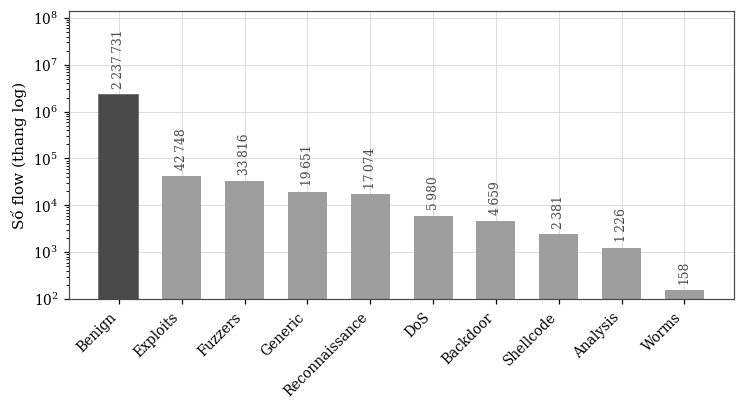

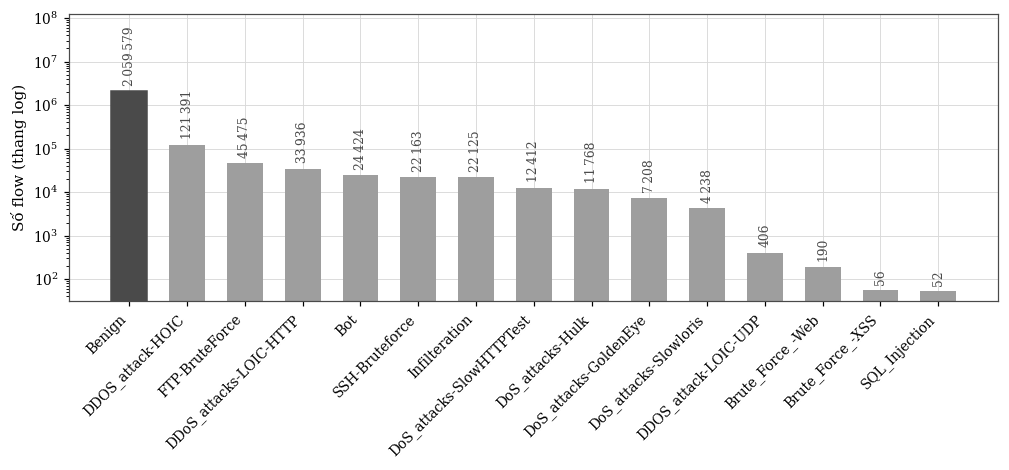

In [6]:
CELL = "03_lay_mau"

TARGET_FLOW_COUNT = min(len(frame) for frame in raw_frames.values())
SAMPLE_SEED = 42

frames = {}
sampling_rows = []
for dataset_name, frame in raw_frames.items():
    ratio = min(1.0, TARGET_FLOW_COUNT / len(frame))
    if ratio >= 1.0:
        sampled = frame
    else:
        sampled = (frame.groupby(ATTACK_COLUMN, group_keys=False)
                        .sample(frac=ratio, random_state=SAMPLE_SEED)
                        .sort_index())
    frames[dataset_name] = sampled
    sampling_rows.append({
        "dataset": dataset_name,
        "flow_count_before": len(frame),
        "flow_count_after": len(sampled),
        "sample_ratio": ratio,
        "attack_rate_before": float(frame[LABEL_COLUMN].astype(int).mean()),
        "attack_rate_after": float(sampled[LABEL_COLUMN].astype(int).mean()),
        "class_count_after": int(sampled[ATTACK_COLUMN].nunique()),
        "graph_nodes_before": int(pd.concat(
            [frame[SOURCE_COLUMN], frame["IPV4_DST_ADDR"]]).astype(str).nunique()),
        "graph_nodes_after": int(pd.concat(
            [sampled[SOURCE_COLUMN], sampled["IPV4_DST_ADDR"]]).astype(str).nunique()),
    })
    row = sampling_rows[-1]
    print(f"{dataset_name}")
    print(f"  {len(frame):>12,} -> {len(sampled):>12,} flow  (tỷ lệ {ratio:.4f})")
    print(f"  tỷ lệ tấn công {frame[LABEL_COLUMN].astype(int).mean() * 100:.4f}% "
          f"-> {sampled[LABEL_COLUMN].astype(int).mean() * 100:.4f}%")
    print(f"  đỉnh đồ thị   : {row['graph_nodes_before']:,} -> {row['graph_nodes_after']:,}")
    print(f"  số lớp giữ lại : {sampled[ATTACK_COLUMN].nunique()}")

fig_lib.export_table(sampling_rows, cell_dir(CELL, "tables"), "lay_mau")

for dataset_name, frame in frames.items():
    class_counts = frame[ATTACK_COLUMN].astype(str).value_counts().to_dict()
    fig_lib.plot_class_distribution(
        class_counts, cell_dir(CELL, "figures"),
        name=f"phan_bo_lop_{dataset_name.replace('-', '_').lower()}")
    plt.show()

## Chia dữ liệu

Notebook chỉ dùng lát cắt thời gian khi có đủ hai điều kiện:

- Dữ liệu có mốc bắt đầu luồng
- Mọi loại tấn công vẫn xuất hiện ở cả ba tập sau khi cắt

NF-UNSW-NB15-v3 đạt cả hai điều kiện nên được sắp theo `FLOW_START_MILLISECONDS` rồi chia 80/10/10

NF-CSE-CIC-IDS2018-v3 không đạt điều kiện thứ hai:

- Tập huấn luyện còn 13/14 lớp tấn công
- Tập kiểm định chỉ còn 1/14 lớp
- Tập kiểm thử chỉ còn 2/14 lớp
- Toàn bộ 24.424 luồng `Bot` rơi vào tập kiểm thử

Vì vậy bộ CSE dùng chia phân tầng theo giao thức GraphIDS, và kết quả từ hai cách chia không được so trực tiếp với nhau


In [7]:
CELL = "04_chia_tap"

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
SPLIT_SEED = 42


def split_by_time(frame, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    # Chia dữ liệu 80/10/10 theo mốc thời gian
    ordered = frame.sort_values(TIME_COLUMN, kind="mergesort").reset_index(drop=True)
    total = len(ordered)
    train_end = int(total * train_ratio)
    val_end = int(total * (train_ratio + val_ratio))
    return {
        "train": ordered.iloc[:train_end].copy(),
        "val": ordered.iloc[train_end:val_end].copy(),
        "test": ordered.iloc[val_end:].copy(),
    }


def split_stratified(frame, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO,
                     seed=SPLIT_SEED):
    # Chia 80/10/10 và giữ phân bố từng loại tấn công
    generator = np.random.default_rng(seed)
    parts = {"train": [], "val": [], "test": []}
    for _, group in frame.groupby(ATTACK_COLUMN, sort=True):
        indices = group.index.to_numpy()
        generator.shuffle(indices)
        total = len(indices)
        train_end = int(total * train_ratio)
        val_end = int(total * (train_ratio + val_ratio))
        parts["train"].append(indices[:train_end])
        parts["val"].append(indices[train_end:val_end])
        parts["test"].append(indices[val_end:])
    ordered = {}
    for name, chunks in parts.items():
        part = frame.loc[np.sort(np.concatenate(chunks))]
        if TIME_COLUMN in part.columns:
            part = part.sort_values(TIME_COLUMN, kind="mergesort")
        ordered[name] = part.copy()
    return ordered


def time_split_is_usable(frame):
    # Kiểm tra có thể chia theo thời gian mà vẫn đủ lớp hay không
    if TIME_COLUMN not in frame.columns:
        return False, f"bộ dữ liệu không có cột {TIME_COLUMN}"

    all_classes = set(frame[ATTACK_COLUMN].astype(str).unique())
    shortfalls = []
    for part_name, part in split_by_time(frame).items():
        absent = all_classes - set(part[ATTACK_COLUMN].astype(str).unique())
        if absent:
            shortfalls.append(f"tập {part_name} vắng {len(absent)} lớp "
                              f"({', '.join(sorted(absent)[:3])}"
                              f"{'...' if len(absent) > 3 else ''})")
    if shortfalls:
        return False, "lát cắt theo thời gian làm " + "; ".join(shortfalls)
    return True, ""


splits = {}
split_methods = {}
split_reasons = {}
for dataset_name, frame in frames.items():
    usable, reason = time_split_is_usable(frame)
    if usable:
        splits[dataset_name] = split_by_time(frame)
        split_methods[dataset_name] = "theo trình tự thời gian"
        split_reasons[dataset_name] = ("mọi loại tấn công đều có mặt ở cả ba "
                                       "tập sau lát cắt thời gian")
    else:
        splits[dataset_name] = split_stratified(frame)
        split_methods[dataset_name] = "phân tầng giữ nguyên phân bố lớp"
        split_reasons[dataset_name] = reason

PROTOCOL_LABELS = {
    "theo trình tự thời gian": "chronological_80_10_10",
    "phân tầng giữ nguyên phân bố lớp": "graphids",
}
protocol_labels = {name: PROTOCOL_LABELS[method]
                   for name, method in split_methods.items()}

sequence_variables = {
    name: (TIME_COLUMN if TIME_COLUMN in frames[name].columns
           else "vị trí dòng trong tệp (không phải thời gian)")
    for name in splits}

for dataset_name, parts in splits.items():
    print(f"{dataset_name}  —  {split_methods[dataset_name]}")
    print(f"  căn cứ chọn  : {split_reasons[dataset_name]}")
    print(f"  biến trình tự: {sequence_variables[dataset_name]}")
    for part_name in ("train", "val", "test"):
        part = parts[part_name]
        attacks = int(part[LABEL_COLUMN].astype(int).sum())
        print(f"  {part_name:<6} {len(part):>10,} flow "
              f"({len(part) / len(frames[dataset_name]) * 100:5.2f}%) | "
              f"{attacks:>8,} tấn công ({attacks / len(part) * 100:6.3f}%)")
    print()

NF-UNSW-NB15-v3  —  theo trình tự thời gian
  căn cứ chọn  : mọi loại tấn công đều có mặt ở cả ba tập sau lát cắt thời gian
  biến trình tự: FLOW_START_MILLISECONDS
  train   1,892,339 flow (80.00%) |   86,301 tấn công ( 4.561%)
  val       236,542 flow (10.00%) |   21,296 tấn công ( 9.003%)
  test      236,543 flow (10.00%) |   20,096 tấn công ( 8.496%)

NF-CSE-CIC-IDS2018-v3  —  phân tầng giữ nguyên phân bố lớp
  căn cứ chọn  : lát cắt theo thời gian làm tập train vắng 1 lớp (Bot); tập val vắng 13 lớp (Bot, Brute_Force_-Web, Brute_Force_-XSS...); tập test vắng 12 lớp (Brute_Force_-Web, Brute_Force_-XSS, DDOS_attack-HOIC...)
  biến trình tự: FLOW_START_MILLISECONDS
  train   1,892,332 flow (80.00%) |  244,669 tấn công (12.929%)
  val       236,542 flow (10.00%) |   30,584 tấn công (12.930%)
  test      236,549 flow (10.00%) |   30,591 tấn công (12.932%)



## Kiểm tra sau khi chia

Đoạn code bên dưới kiểm tra tỷ lệ, phần giao nhau giữa các tập và sự có mặt của từng lớp

Riêng với phép chia theo thời gian, notebook kiểm tra thêm:

- Mốc thời gian không đi lùi trong từng tập
- Ranh giới giữa ba tập không chồng lên nhau

UNSW-NB15-v3 có hai đợt thu thập cách nhau khoảng 624 giờ, nhưng lát cắt 80/10/10 nằm trong đợt thứ hai, do đó phép chia đúng về thứ tự nhưng chưa phải bài kiểm tra trên một giai đoạn thu thập hoàn toàn mới


NF-UNSW-NB15-v3: đạt cả năm tính chất
  cách chia    : theo trình tự thời gian
  tỷ lệ ba tập : 0.8000 / 0.1000 / 0.1000
  ranh giới thời gian train kết thúc 1,424,246,259,997
                       val   bắt đầu 1,424,246,259,998
                       test  bắt đầu 1,424,254,516,414
  số lớp có mặt trong tập huấn luyện: 10/10

NF-CSE-CIC-IDS2018-v3: đạt cả ba tính chất áp dụng được
  cách chia    : phân tầng giữ nguyên phân bố lớp
  tỷ lệ ba tập : 0.8000 / 0.1000 / 0.1000
  lý do không chia theo thời gian: lát cắt theo thời gian làm tập train vắng 1 lớp (Bot); tập val vắng 13 lớp (Bot, Brute_Force_-Web, Brute_Force_-XSS...); tập test vắng 12 lớp (Brute_Force_-Web, Brute_Force_-XSS, DDOS_attack-HOIC...)
  hai tính chất về trình tự thời gian không áp dụng cho cách chia này
  biến trình tự: FLOW_START_MILLISECONDS
  số lớp có mặt trong tập huấn luyện: 15/15



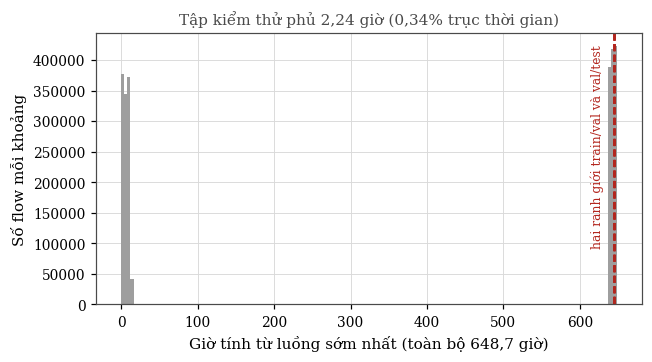

In [8]:
CELL = "05_tu_kiem_chia_tap"

check_rows = []
for dataset_name, parts in splits.items():
    total = sum(len(part) for part in parts.values())
    ratios = {name: len(part) / total for name, part in parts.items()}

    assert abs(ratios["train"] - TRAIN_RATIO) < 1e-3, (
        f"{dataset_name}: tỷ lệ tập huấn luyện là {ratios['train']:.4f}, "
        f"khác mức khai báo {TRAIN_RATIO}")
    assert abs(ratios["val"] - VAL_RATIO) < 1e-3, (
        f"{dataset_name}: tỷ lệ tập kiểm định là {ratios['val']:.4f}, "
        f"khác mức khai báo {VAL_RATIO}")

    index_sets = {name: set(part.index) for name, part in parts.items()}
    assert not (index_sets["train"] & index_sets["val"]), f"{dataset_name}: train và val giao nhau"
    assert not (index_sets["val"] & index_sets["test"]), f"{dataset_name}: val và test giao nhau"
    assert not (index_sets["train"] & index_sets["test"]), f"{dataset_name}: train và test giao nhau"

    classes_all = set(frames[dataset_name][ATTACK_COLUMN].astype(str).unique())
    classes_train = set(parts["train"][ATTACK_COLUMN].astype(str).unique())
    missing_classes = classes_all - classes_train
    assert not missing_classes, (
        f"{dataset_name}: các lớp {sorted(missing_classes)} không có trong tập "
        f"huấn luyện")

    row = {
        "dataset": dataset_name,
        "split_method": split_methods[dataset_name],
        "train_ratio": ratios["train"], "val_ratio": ratios["val"],
        "test_ratio": ratios["test"],
        "disjoint_index": True,
        "all_classes_in_train": True,
        "class_count": len(classes_all),
        "sequence_variable": sequence_variables[dataset_name],
    }

    if split_methods[dataset_name] == "theo trình tự thời gian":
        boundaries = {}
        for part_name, part in parts.items():
            timestamps = part[TIME_COLUMN].values
            assert np.all(np.diff(timestamps) >= 0), (
                f"{dataset_name}: mốc thời gian trong tập {part_name} không tăng dần")
            boundaries[part_name] = (int(timestamps.min()), int(timestamps.max()))
        assert boundaries["train"][1] <= boundaries["val"][0], (
            f"{dataset_name}: khoảng thời gian của train và val chồng lấn")
        assert boundaries["val"][1] <= boundaries["test"][0], (
            f"{dataset_name}: khoảng thời gian của val và test chồng lấn")
        row.update({
            "monotonic_time": True, "no_time_overlap": True,
            "train_time_end": boundaries["train"][1],
            "val_time_start": boundaries["val"][0],
            "val_time_end": boundaries["val"][1],
            "test_time_start": boundaries["test"][0],
        })
        print(f"{dataset_name}: đạt cả năm tính chất")
        print(f"  cách chia    : {split_methods[dataset_name]}")
        print(f"  tỷ lệ ba tập : {ratios['train']:.4f} / {ratios['val']:.4f} / {ratios['test']:.4f}")
        print(f"  ranh giới thời gian train kết thúc {boundaries['train'][1]:,}")
        print(f"                       val   bắt đầu {boundaries['val'][0]:,}")
        print(f"                       test  bắt đầu {boundaries['test'][0]:,}")
    else:
        row.update({
            "monotonic_time": None, "no_time_overlap": None,
            "train_time_end": None, "val_time_start": None,
            "val_time_end": None, "test_time_start": None,
        })

        for part_name, part in parts.items():
            if TIME_COLUMN in part.columns:
                order = part[TIME_COLUMN].to_numpy()
            else:
                order = part.index.to_numpy()
            assert np.all(np.diff(order) >= 0), (
                f"{dataset_name}: tập {part_name} chưa được sắp lại theo trình "
                f"tự sau khi phân tầng")
        row["order_restored"] = True
        row["split_reason"] = split_reasons[dataset_name]
        print(f"{dataset_name}: đạt cả ba tính chất áp dụng được")
        print(f"  cách chia    : {split_methods[dataset_name]}")
        print(f"  tỷ lệ ba tập : {ratios['train']:.4f} / {ratios['val']:.4f} / {ratios['test']:.4f}")
        print(f"  lý do không chia theo thời gian: {split_reasons[dataset_name]}")
        print(f"  hai tính chất về trình tự thời gian không áp dụng cho cách "
              f"chia này")
        print(f"  biến trình tự: {sequence_variables[dataset_name]}")
        if sequence_variables[dataset_name] != TIME_COLUMN:
            print(f"  vị trí dòng chỉ cấp một thứ tự đơn điệu cho bộ mã hoá "
                  f"thời gian của mô hình; nó không phải một đại lượng quan "
                  f"sát được và không tham gia vào bất kỳ chỉ số nào được báo cáo")
    print(f"  số lớp có mặt trong tập huấn luyện: {len(classes_train)}/{len(classes_all)}")
    print()
    check_rows.append(row)

fig_lib.export_table(check_rows, cell_dir(CELL, "tables"), "tu_kiem_chia_tap")
fig_lib.write_manifest(cell_dir(CELL, "metrics"),
                       {"train_ratio": TRAIN_RATIO, "val_ratio": VAL_RATIO,
                        "split_seed": SPLIT_SEED, "checks": check_rows},
                       name="tu_kiem_chia_tap")

for dataset_name, parts in splits.items():
    if split_methods[dataset_name] != "theo trình tự thời gian":
        continue
    if TIME_COLUMN not in frames[dataset_name].columns:
        continue
    fig_lib.plot_time_distribution(
        frames[dataset_name][TIME_COLUMN].values,
        [len(parts["train"]), len(parts["val"]), len(parts["test"])],
        cell_dir(CELL, "figures"),
        name=f"phan_bo_thoi_gian_{dataset_name.lower().replace('-', '_')}")
    plt.show()

## Tham số huấn luyện

Các giá trị dưới đây được giữ cố định cho hai notebook để mọi lần chạy dùng cùng
một cấu hình:

- `memory_dim`, `embedding_dim`, `hidden_dim`: 192 để ba khối biểu diễn nối được với nhau
- `time_dim`: 64 để mã hóa thông tin thời gian trong một không gian riêng
- `num_heads`: 8, tương ứng 24 chiều cho mỗi head khi embedding có 192 chiều
- `num_layers`: 1 để giữ kiến trúc gọn và giảm chi phí trên các bộ dữ liệu lớn
- `mask_ratio`: 0,15 để bài toán dựng lại vẫn có đủ thuộc tính quan sát
- `dropout` của encoder: 0,1 vì encoder học tự giám sát trên nhiều luồng lành tính
- `classifier_dropout`: 0,3 ở đầu phân loại, lấy từ giá trị mặc định của `ExperimentConfig`, vì giai đoạn này học có giám sát trên các lớp ít mẫu
- `batch_size`: 512 để giữ cùng điều kiện tính toán giữa các bộ dữ liệu
- `learning_rate`: 1e-4 và `weight_decay`: 1e-5 để cập nhật ổn định với mức regularization nhẹ
- `seed`: 42 để phép chia và lần chạy có thể lặp lại

Ngân sách tối đa là 150 epoch ở giai đoạn một và 100 epoch ở giai đoạn hai
Patience lần lượt là 25 và 15 để early stopping không dừng ngay trong đoạn loss đi ngang
Checkpoint tốt nhất chọn theo PR-AUC ở giai đoạn một và Macro F1 trên tập kiểm định ở giai đoạn hai


In [9]:
CELL = "06_tham_so"

MEMORY_DIM = 192
EMBEDDING_DIM = 192
TIME_DIM = 64
HIDDEN_DIM = 192
NUM_HEADS = 8
NUM_LAYERS = 1
DROPOUT = 0.1

MASK_RATIO = 0.15

EPOCHS_STAGE_ONE = 150
PATIENCE_STAGE_ONE = 25
EPOCHS_STAGE_TWO = 100
PATIENCE_STAGE_TWO = 15

BATCH_SIZE = 512
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
LOG_EVERY_EPOCHS = 10
SEED = 42

parameter_rows = [
    {"nhóm": "Biểu diễn", "tham số": "memory_dim", "giá trị": MEMORY_DIM},
    {"nhóm": "Biểu diễn", "tham số": "embedding_dim", "giá trị": EMBEDDING_DIM},
    {"nhóm": "Biểu diễn", "tham số": "time_dim", "giá trị": TIME_DIM},
    {"nhóm": "Biểu diễn", "tham số": "hidden_dim", "giá trị": HIDDEN_DIM},
    {"nhóm": "Biểu diễn", "tham số": "num_heads", "giá trị": NUM_HEADS},
    {"nhóm": "Biểu diễn", "tham số": "num_layers", "giá trị": NUM_LAYERS},
    {"nhóm": "Biểu diễn", "tham số": "dropout", "giá trị": DROPOUT},
    {"nhóm": "Giai đoạn một", "tham số": "mask_ratio", "giá trị": MASK_RATIO},
    {"nhóm": "Giai đoạn một", "tham số": "num_epochs", "giá trị": EPOCHS_STAGE_ONE},
    {"nhóm": "Giai đoạn một", "tham số": "patience", "giá trị": PATIENCE_STAGE_ONE},
    {"nhóm": "Giai đoạn hai", "tham số": "num_epochs", "giá trị": EPOCHS_STAGE_TWO},
    {"nhóm": "Giai đoạn hai", "tham số": "patience", "giá trị": PATIENCE_STAGE_TWO},
    {"nhóm": "Tối ưu", "tham số": "batch_size", "giá trị": BATCH_SIZE},
    {"nhóm": "Tối ưu", "tham số": "learning_rate", "giá trị": LEARNING_RATE},
    {"nhóm": "Tối ưu", "tham số": "weight_decay", "giá trị": WEIGHT_DECAY},
    {"nhóm": "Tái lập", "tham số": "seed", "giá trị": SEED},
]
fig_lib.export_table(parameter_rows, cell_dir(CELL, "tables"), "tham_so")

print(f"{'Nhóm':<16}{'Tham số':<18}{'Giá trị'}")
for row in parameter_rows:
    print(f"{row['nhóm']:<16}{row['tham số']:<18}{row['giá trị']}")

Nhóm            Tham số           Giá trị
Biểu diễn       memory_dim        192
Biểu diễn       embedding_dim     192
Biểu diễn       time_dim          64
Biểu diễn       hidden_dim        192
Biểu diễn       num_heads         8
Biểu diễn       num_layers        1
Biểu diễn       dropout           0.1
Giai đoạn một   mask_ratio        0.15
Giai đoạn một   num_epochs        150
Giai đoạn một   patience          25
Giai đoạn hai   num_epochs        100
Giai đoạn hai   patience          15
Tối ưu          batch_size        512
Tối ưu          learning_rate     0.0001
Tối ưu          weight_decay      1e-05
Tái lập         seed              42


## Học biểu diễn từ lưu lượng lành tính

Ở giai đoạn đầu, mô hình chỉ học từ các luồng lành tính:

- Che một phần thuộc tính của luồng
- Dùng ngữ cảnh đồ thị để dựng lại phần bị che
- Lấy sai số dựng lại làm anomaly score

Ngưỡng được chọn trên tập kiểm định bằng Macro F1 rồi giữ nguyên khi chấm tập kiểm thử

Khi đọc kết quả, cần đặt Macro F1 cạnh recall của lớp tấn công vì Macro F1 vẫn có thể tăng trong lúc mô hình bỏ sót thêm tấn công, còn checkpoint được chọn bằng PR-AUC để tránh phụ thuộc vào ngưỡng


NF-UNSW-NB15-v3: loại 86,301 luồng tấn công khỏi tập huấn luyện, còn 1,806,038 luồng lành tính

------
Thí nghiệm: stage1_nf_unsw_nb15_v3
Mô tả: Giai đoạn một, học biểu diễn tự giám sát trên NF-UNSW-NB15-v3
Protocol: chronological_80_10_10 | Task: binary | Mode: self_supervised | Device: cuda
------
Dùng tập đã phân chia sẵn do phía gọi cung cấp, bỏ qua giao thức 'chronological_80_10_10'
Train:   1,806,038 flow |        0 attack
Val:       236,542 flow |   21,296 attack
Test:      236,543 flow |   20,096 attack
------
Danh mục nhãn: 10 lớp | Benign ở vị trí 2
Edge features: 49 | Số node: 44
Masked reconstruction: che 7/49 thuộc tính mỗi cạnh (mask_ratio 0.15)
Tham số: 1,539,441
------
Epoch   1 | Train loss:    0.31461 | Val loss:   10.27528 | Val pr_auc:   0.95883
Epoch  10 | Train loss:    0.09672 | Val loss:    3.81452 | Val pr_auc:   0.98723
Epoch  20 | Train loss:    0.07355 | Val loss:    1.61833 | Val pr_auc:   0.98554
Epoch  30 | Train loss:    0.08315 | Val loss:    1.43105 | 

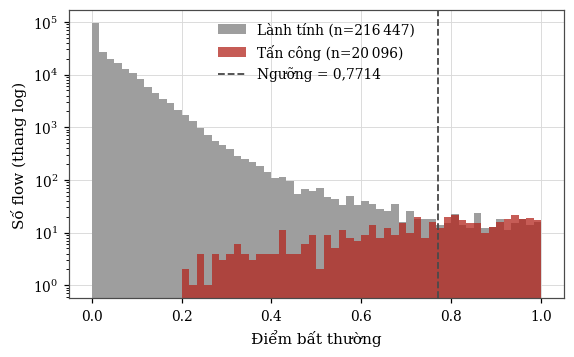

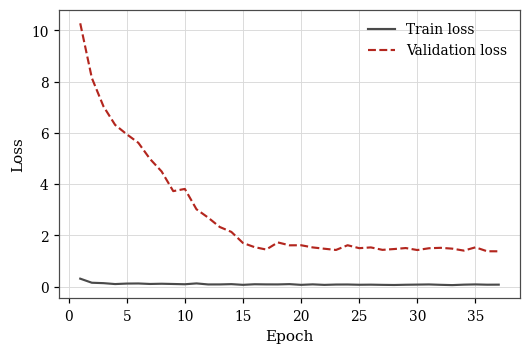

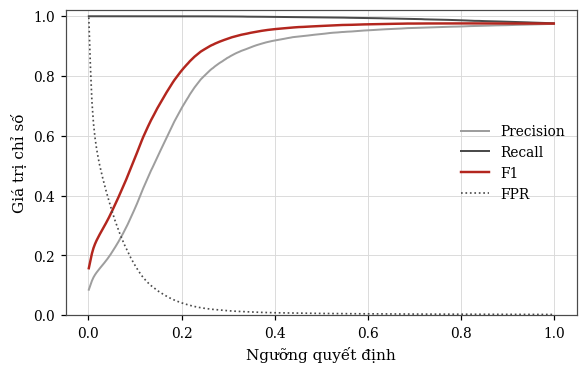

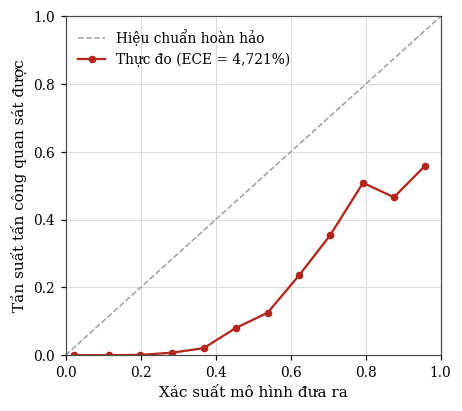

NF-CSE-CIC-IDS2018-v3: loại 244,669 luồng tấn công khỏi tập huấn luyện, còn 1,647,663 luồng lành tính

------
Thí nghiệm: stage1_nf_cse_cic_ids2018_v3
Mô tả: Giai đoạn một, học biểu diễn tự giám sát trên NF-CSE-CIC-IDS2018-v3
Protocol: graphids | Task: binary | Mode: self_supervised | Device: cuda
------
Dùng tập đã phân chia sẵn do phía gọi cung cấp, bỏ qua giao thức 'graphids'
Train:   1,647,663 flow |        0 attack
Val:       236,542 flow |   30,584 attack
Test:      236,549 flow |   30,591 attack
------
Danh mục nhãn: 15 lớp | Benign ở vị trí 0
Edge features: 49 | Số node: 76,007
Masked reconstruction: che 7/49 thuộc tính mỗi cạnh (mask_ratio 0.15)
Tham số: 1,539,441
------
Epoch   1 | Train loss:    0.99699 | Val loss:   14.84118 | Val pr_auc:   0.13743
Epoch  10 | Train loss:    0.81125 | Val loss:   14.66140 | Val pr_auc:   0.17423
Epoch  20 | Train loss:    0.73778 | Val loss:   14.66083 | Val pr_auc:   0.17754
Epoch  30 | Train loss:    0.78075 | Val loss:   14.64791 | Val p

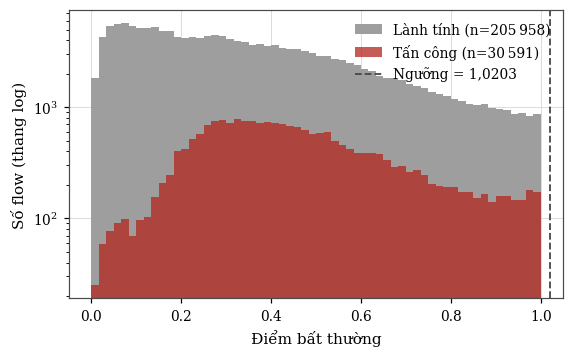

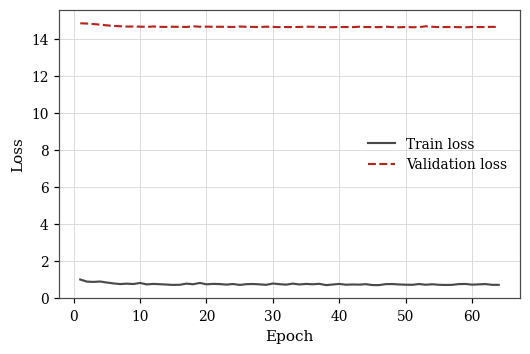

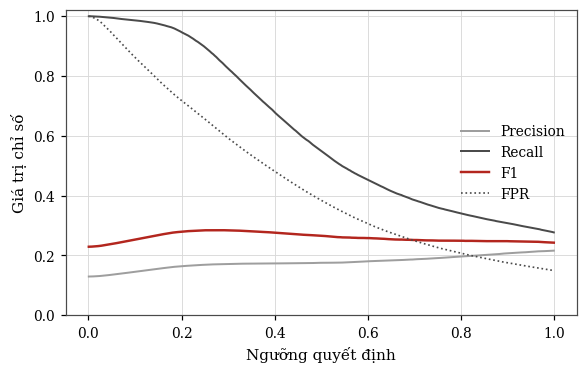

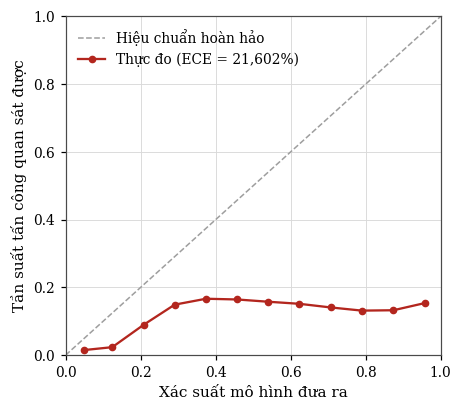

In [10]:
CELL = "07_giai_doan_mot"

stage_one_results = {}
stage_one_checkpoints = {}

for dataset_name, parts in splits.items():
    benign_train = parts["train"][parts["train"][LABEL_COLUMN].astype(int) == 0]
    stage_one_splits = {
        "train": benign_train.copy(),
        "val": parts["val"].copy(),
        "test": parts["test"].copy(),
    }
    removed = len(parts["train"]) - len(benign_train)
    print(f"{dataset_name}: loại {removed:,} luồng tấn công khỏi tập huấn luyện, "
          f"còn {len(benign_train):,} luồng lành tính")

    run_name = f"stage1_{dataset_name.replace('-', '_').lower()}"
    config = ExperimentConfig(
        name=run_name,
        description=f"Giai đoạn một, học biểu diễn tự giám sát trên {dataset_name}",
        protocol=protocol_labels[dataset_name],
        task="binary",
        mode="self_supervised",
        memory_dim=MEMORY_DIM, embedding_dim=EMBEDDING_DIM, time_dim=TIME_DIM,
        hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
        dropout=DROPOUT, mask_ratio=MASK_RATIO,
        batch_size=BATCH_SIZE, num_epochs=EPOCHS_STAGE_ONE,
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        early_stopping_patience=PATIENCE_STAGE_ONE,
        early_stopping_metric="pr_auc",
        log_every_epochs=LOG_EVERY_EPOCHS,
        threshold_strategy="f1",
        seed=SEED,
    )
    result = run_experiment(
        df=frames[dataset_name], config=config,
        preprocessor=NetFlowPreprocessor(),
        output_dir=cell_dir(CELL, "models"),
        splits=stage_one_splits, verbose=True)

    stage_one_results[dataset_name] = result
    stage_one_checkpoints[dataset_name] = os.path.join(
        cell_dir(CELL, "models"), f"model_{run_name}.pt")

    stored = np.load(os.path.join(result["output_dir"], f"predictions_{run_name}.npz"))
    y_true, y_score = stored["y_true"], stored["y_score"]
    figures_dir = cell_dir(CELL, "figures")

    fig_lib.plot_score_distribution(
        y_true, y_score, figures_dir,
        threshold=result.get("threshold"),
        name=f"phan_bo_diem_bat_thuong_{dataset_name.lower().replace('-', '_')}")
    plt.show()

    with tempfile.TemporaryDirectory() as scratch:
        if result.get("history"):
            fig_lib.plot_learning_curve(result["history"], scratch)
            plt.show()
        fig_lib.plot_threshold_sweep(y_true, y_score, scratch)
        plt.show()
        fig_lib.plot_calibration(y_true, y_score, scratch)
        plt.show()

## Phân loại từng loại tấn công

Giai đoạn hai dùng lại encoder đã học và khóa toàn bộ trọng số của encoder, phần duy nhất được huấn luyện thêm là đầu phân loại

Đoạn code bên dưới cũng in số tham số đang được cập nhật để kiểm tra việc đóng băng có đúng hay không

Các đường ROC và Precision-Recall dùng nhãn gộp về hai lớp, vì vậy chúng chỉ cho biết mô hình có nhận ra tấn công hay không, còn khả năng gọi đúng từng loại phải đọc bằng Macro F1 và chỉ số theo lớp



------
Thí nghiệm: stage2_nf_unsw_nb15_v3
Mô tả: Giai đoạn hai, phân loại đa lớp trên NF-UNSW-NB15-v3
Protocol: chronological_80_10_10 | Task: multiclass | Mode: supervised | Device: cuda
------
Dùng tập đã phân chia sẵn do phía gọi cung cấp, bỏ qua giao thức 'chronological_80_10_10'
Train:   1,892,339 flow |   86,301 attack
Val:       236,542 flow |   21,296 attack
Test:      236,543 flow |   20,096 attack
------
Danh mục nhãn: 10 lớp | Benign ở vị trí 2
Edge features: 49 | Số node: 44
Đã nạp bộ mã hoá của giai đoạn thứ nhất từ model_stage1_nf_unsw_nb15_v3.pt
Đã đóng băng khối bộ nhớ thời gian và khối nhúng. Giai đoạn này chỉ huấn luyện đầu phân loại.
Bộ phân loại nhìn đặc trưng cạnh: có
Class weights: Analysis=1.631 Backdoor=0.787 Benign=0.034 DoS=0.714 Exploits=0.270 Fuzzers=0.298 Generic=0.403 Reconnaissance=0.431 Shellcode=1.079 Worms=4.353
Tham số: 122,698
------
Epoch   1 | Train loss:    0.43788 | Val loss:    0.64627 | Val f1_macro:   0.38533
Epoch  10 | Train loss:    0.2576

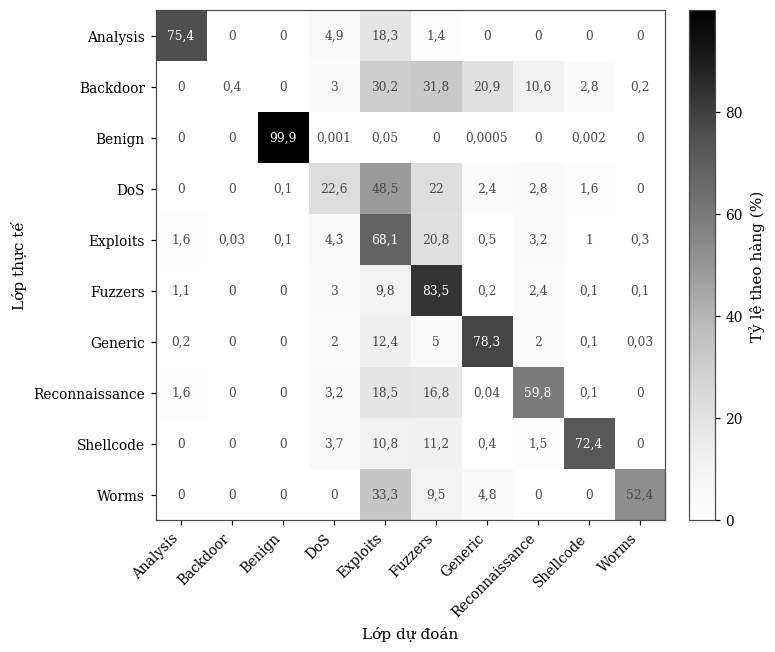

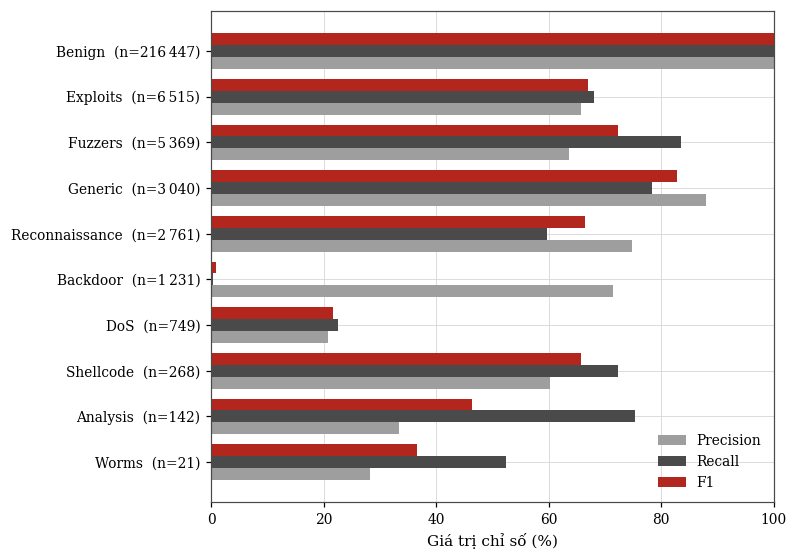

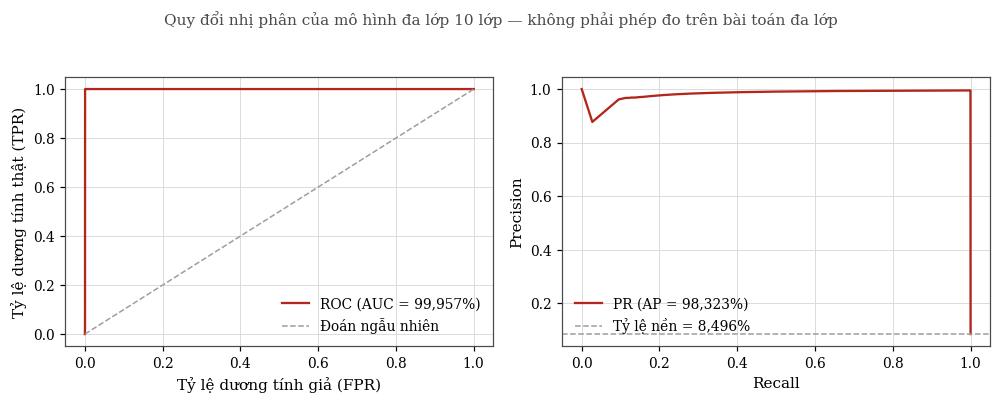

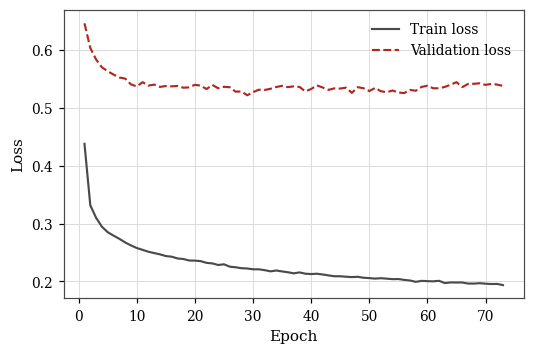


------
Thí nghiệm: stage2_nf_cse_cic_ids2018_v3
Mô tả: Giai đoạn hai, phân loại đa lớp trên NF-CSE-CIC-IDS2018-v3
Protocol: graphids | Task: multiclass | Mode: supervised | Device: cuda
------
Dùng tập đã phân chia sẵn do phía gọi cung cấp, bỏ qua giao thức 'graphids'
Train:   1,892,332 flow |  244,669 attack
Val:       236,542 flow |   30,584 attack
Test:      236,549 flow |   30,591 attack
------
Danh mục nhãn: 15 lớp | Benign ở vị trí 0
Edge features: 49 | Số node: 76,060
Đã nạp bộ mã hoá của giai đoạn thứ nhất từ model_stage1_nf_cse_cic_ids2018_v3.pt
Đã đóng băng khối bộ nhớ thời gian và khối nhúng. Giai đoạn này chỉ huấn luyện đầu phân loại.
Bộ phân loại nhìn đặc trưng cạnh: có
Class weights: Benign=0.022 Bot=0.202 Brute_Force_-Web=2.288 Brute_Force_-XSS=4.253 DDOS_attack-HOIC=0.091 DDOS_attack-LOIC-UDP=1.567 DDoS_attacks-LOIC-HTTP=0.171 DoS_attacks-GoldenEye=0.371 DoS_attacks-Hulk=0.291 DoS_attacks-SlowHTTPTest=0.283 DoS_attacks-Slowloris=0.484 FTP-BruteForce=0.148 Infilteration

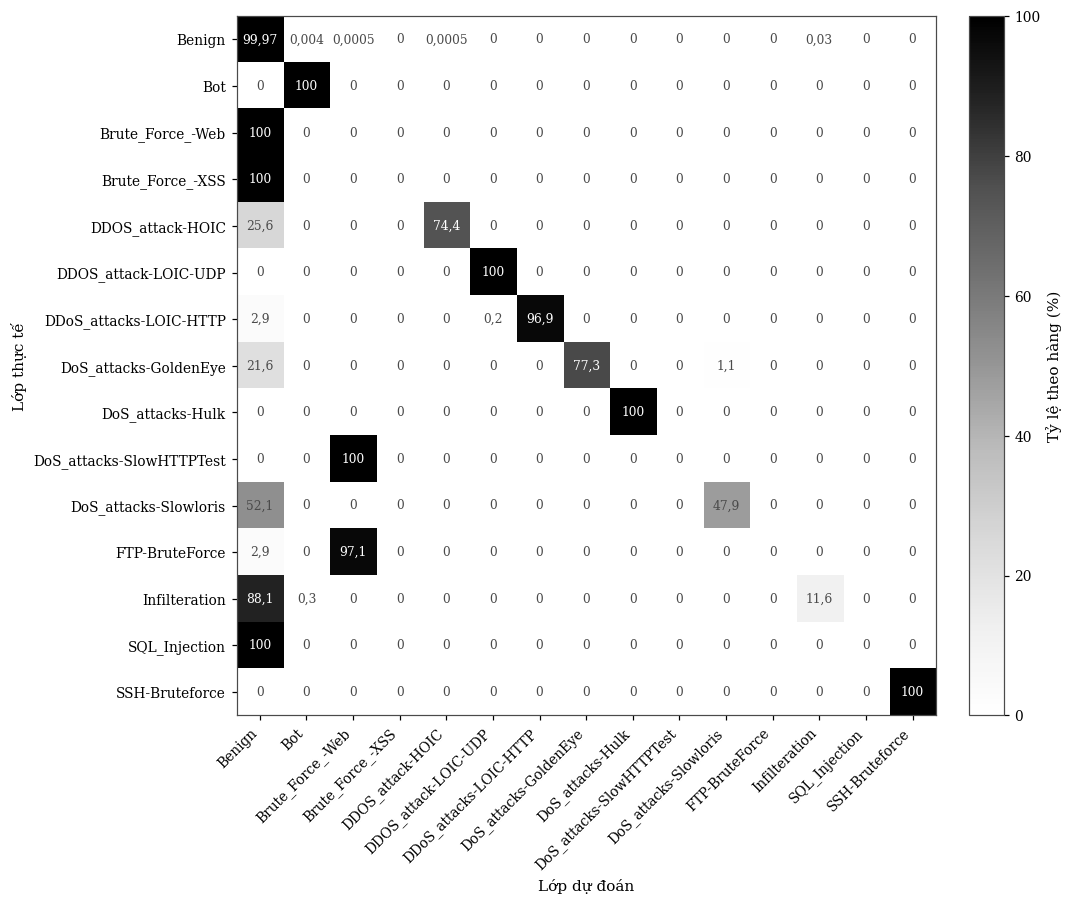

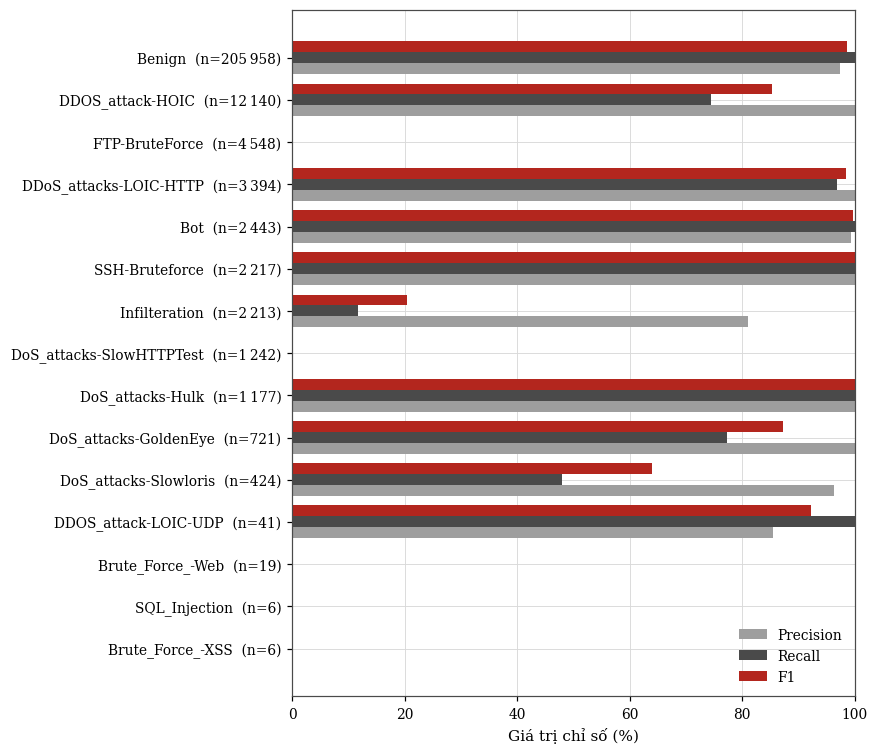

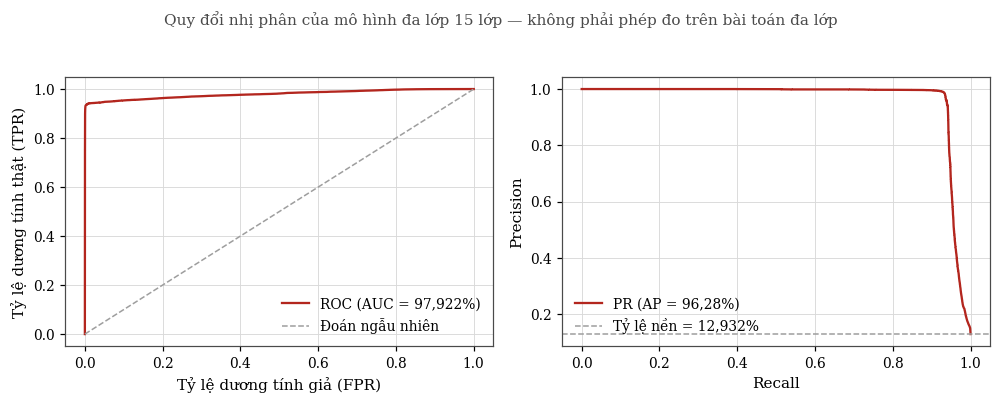

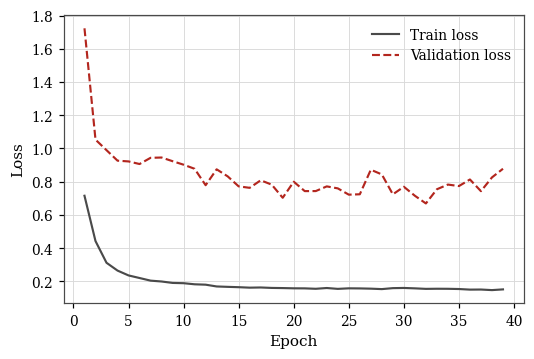

In [11]:
CELL = "08_giai_doan_hai"

stage_two_results = {}

for dataset_name, parts in splits.items():
    run_name = f"stage2_{dataset_name.replace('-', '_').lower()}"
    config = ExperimentConfig(
        name=run_name,
        description=f"Giai đoạn hai, phân loại đa lớp trên {dataset_name}",
        protocol=protocol_labels[dataset_name],
        task="multiclass",
        mode="supervised",
        memory_dim=MEMORY_DIM, embedding_dim=EMBEDDING_DIM, time_dim=TIME_DIM,
        hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        batch_size=BATCH_SIZE, num_epochs=EPOCHS_STAGE_TWO,
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        early_stopping_patience=PATIENCE_STAGE_TWO,
        early_stopping_metric="f1_macro",
        log_every_epochs=LOG_EVERY_EPOCHS,
        pretrained_encoder=stage_one_checkpoints[dataset_name],
        freeze_encoder=True,
        seed=SEED,
    )
    result = run_experiment(
        df=frames[dataset_name], config=config,
        preprocessor=NetFlowPreprocessor(),
        output_dir=cell_dir(CELL, "models"),
        splits=parts, verbose=True)

    stage_two_results[dataset_name] = result

    stored = np.load(os.path.join(result["output_dir"], f"predictions_{run_name}.npz"))
    y_true = stored["y_true"]
    y_score = stored["y_score"]
    figures_dir = cell_dir(CELL, "figures")
    suffix = dataset_name.lower().replace('-', '_')

    confusion = np.asarray(result["metrics"]["confusion_matrix"])
    class_names = result["class_names"]
    if len(class_names) != confusion.shape[0]:
        raise ValueError(
            f"{run_name}: ma trận nhầm lẫn có {confusion.shape[0]} lớp còn "
            f"danh mục tên có {len(class_names)} mục.")

    fig_lib.plot_confusion_matrix(confusion, class_names, figures_dir,
                                  name=f"ma_tran_nham_lan_{suffix}", normalize=True)
    plt.show()

    fig_lib.plot_per_class(result["metrics"]["per_class"], figures_dir,
                           name=f"chi_so_theo_lop_{suffix}")
    plt.show()

    binary_true = (y_true != result["benign_class_id"]).astype(int)
    fig_lib.plot_roc_pr(
        binary_true, y_score, figures_dir,
        name=f"roc_va_pr_nhi_phan_quy_doi_{suffix}",
        title=f"Quy đổi nhị phân của mô hình đa lớp {len(class_names)} lớp "
              f"— không phải phép đo trên bài toán đa lớp")
    plt.show()

    with tempfile.TemporaryDirectory() as scratch:
        if result.get("history"):
            fig_lib.plot_learning_curve(result["history"], scratch)
            plt.show()

## So sánh với các công trình khác

Chỉ đặt hai kết quả cạnh nhau khi chúng dùng cùng bộ dữ liệu và cùng bài toán:

- GraphIDS và Anomal-E: phát hiện nhị phân
- TE-G-SAGE: phân loại nhiều lớp
- Kết quả của đồ án: tách riêng theo đúng hai nhóm trên

Macro F1 luôn đi cùng recall của lớp tấn công, còn F1 nhị phân đi cùng mốc đoán tất cả là tấn công

Không gộp chỉ số nhị phân và nhiều lớp vào cùng một biểu đồ vì hai con số trả lời hai câu hỏi khác nhau


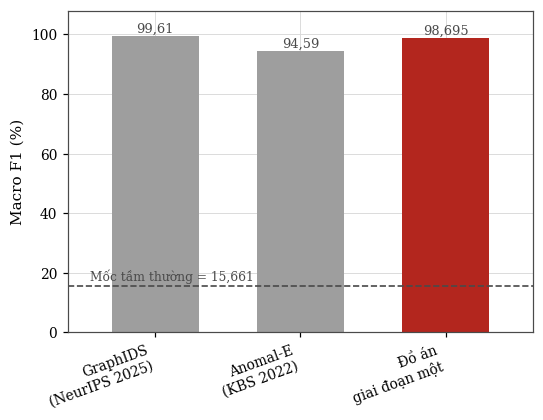

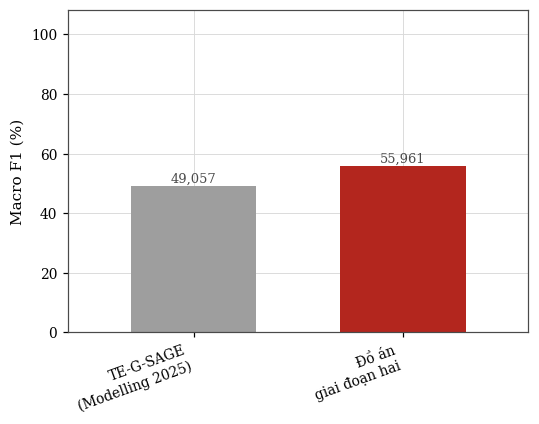

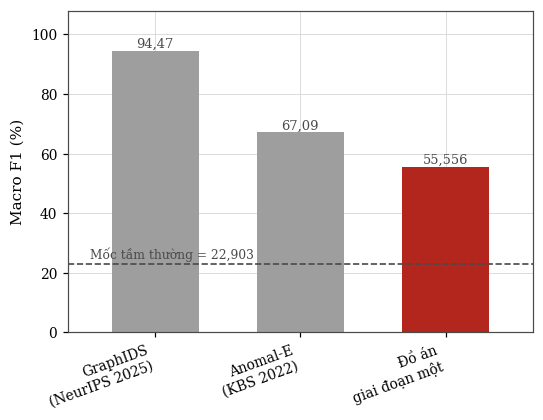

NF-CSE-CIC-IDS2018-v3, bài toán đa lớp: không công trình đối sánh nào công bố chỉ số trên bộ này, bỏ qua biểu đồ
Bộ dữ liệu              Bài toán  Hệ thống                    Macro F1  Recall tấn công      Mốc
NF-UNSW-NB15-v3         nhị phân  Đồ án giai đoạn một          98.695%          98.791%  15.661%
NF-UNSW-NB15-v3         nhị phân  GraphIDS (NeurIPS 2025)      99.610%                —  15.661%
NF-UNSW-NB15-v3         nhị phân  Anomal-E (KBS 2022)          94.590%                —  15.661%
NF-UNSW-NB15-v3         đa lớp    Đồ án giai đoạn hai          55.961%          99.955%        —
NF-UNSW-NB15-v3         đa lớp    TE-G-SAGE (Modelling 2025)   49.057%                —        —
NF-CSE-CIC-IDS2018-v3   nhị phân  Đồ án giai đoạn một          55.556%          26.887%  22.903%
NF-CSE-CIC-IDS2018-v3   nhị phân  GraphIDS (NeurIPS 2025)      94.470%                —  22.903%
NF-CSE-CIC-IDS2018-v3   nhị phân  Anomal-E (KBS 2022)          67.090%                —  22.903%
NF-CSE-CIC-IDS

In [12]:
CELL = "09_doi_sanh_cong_bo"

PUBLISHED_MACRO_F1 = {
    "NF-UNSW-NB15-v3": {
        "binary": {
            "GraphIDS\n(NeurIPS 2025)": (0.9961, "Bảng 3, độ lệch chuẩn 0,0084"),
            "Anomal-E\n(KBS 2022)": (0.9459, "Bảng 3, do nhóm GraphIDS chạy lại"),
        },
        "multiclass": {
            "TE-G-SAGE\n(Modelling 2025)": (0.49057, "Bảng 7, chia 60/30/10 theo trình tự thời gian"),
        },
    },
    "NF-CSE-CIC-IDS2018-v3": {
        "binary": {
            "GraphIDS\n(NeurIPS 2025)": (0.9447, "Bảng 3, độ lệch chuẩn 0,0213"),
            "Anomal-E\n(KBS 2022)": (0.6709, "Bảng 3, do nhóm GraphIDS chạy lại"),
        },
        "multiclass": {},
    },
}

TASK_LABELS = {"binary": ("nhi_phan", "nhị phân"),
               "multiclass": ("da_lop", "đa lớp")}


def attack_recall(result):
    # Lấy recall của lớp tấn công theo đúng bài toán
    metrics = result["metrics"]
    if result["config"]["task"] == "multiclass":
        equivalent = metrics.get("binary_equivalent") or {}
        return equivalent.get("recall")
    return metrics.get("recall")


comparison_rows = []
for dataset_name, parts in splits.items():
    test_attack_rate = float(parts["test"][LABEL_COLUMN].astype(int).mean())
    trivial = fig_lib.trivial_f1(test_attack_rate)

    measured_by_task = {
        "binary": ("Đồ án\ngiai đoạn một", stage_one_results[dataset_name]),
        "multiclass": ("Đồ án\ngiai đoạn hai", stage_two_results[dataset_name]),
    }

    for task, (our_label, our_result) in measured_by_task.items():
        file_tag, task_vn = TASK_LABELS[task]
        published = PUBLISHED_MACRO_F1[dataset_name][task]

        if not published:
            print(f"{dataset_name}, bài toán {task_vn}: không công trình đối "
                  f"sánh nào công bố chỉ số trên bộ này, bỏ qua biểu đồ")
        else:
            figure, _ = fig_lib.plot_baseline_comparison(
                {our_label: our_result["metrics"]["f1_macro"]},
                {name: {"f1_macro": value} for name, (value, _) in published.items()},
                "f1_macro", cell_dir(CELL, "figures"),
                name=f"doi_sanh_{file_tag}_{dataset_name.replace('-', '_').lower()}",
                trivial=trivial if task == "binary" else None,
                ylabel="Macro F1")
            plt.show()

        comparison_rows.append({
            "dataset": dataset_name, "task": task_vn, "system": our_label.replace("\n", " "),
            "source": "đo được trong đồ án",
            "f1_macro": our_result["metrics"]["f1_macro"],
            "attack_recall": attack_recall(our_result),
            "trivial_f1_baseline": trivial if task == "binary" else None,
            "exceeds_trivial_baseline": (
                bool(our_result["metrics"]["f1_macro"] > trivial)
                if task == "binary" else None),
            "note": ""})
        for name, (value, note) in published.items():
            comparison_rows.append({
                "dataset": dataset_name, "task": task_vn,
                "system": name.replace("\n", " "), "source": "chỉ số công bố",
                "f1_macro": value,
                "attack_recall": None,
                "trivial_f1_baseline": trivial if task == "binary" else None,
                "exceeds_trivial_baseline": (bool(value > trivial)
                                             if task == "binary" else None),
                "note": note})

fig_lib.export_table(comparison_rows, cell_dir(CELL, "tables"), "doi_sanh_cong_bo")

print(f"{'Bộ dữ liệu':<24}{'Bài toán':<10}{'Hệ thống':<26}"
      f"{'Macro F1':>10}{'Recall tấn công':>17}{'Mốc':>9}")
for row in comparison_rows:
    recall = ("—" if row["attack_recall"] is None
              else f"{row['attack_recall'] * 100:.3f}%")
    trivial_text = ("—" if row["trivial_f1_baseline"] is None
                    else f"{row['trivial_f1_baseline'] * 100:.3f}%")
    print(f"{row['dataset']:<24}{row['task']:<10}{row['system']:<26}"
          f"{row['f1_macro'] * 100:>9.3f}%{recall:>17}{trivial_text:>9}")

## Tổng hợp kết quả

Bảng bên dưới gom bốn lần chạy:

- Hai bộ dữ liệu
- Hai giai đoạn cho mỗi bộ

Khi đưa số liệu vào báo cáo, lấy từ tệp bảng được lưu ở cell này thay vì chép từ phần output

Cột vòng tốt nhất cần đọc cùng số vòng đã chạy để biết mô hình dừng sớm bình thường hay đã chạm giới hạn epoch


In [13]:
CELL = "10_tong_hop"

summary_rows = []
for dataset_name in splits:
    for stage_label, results in (("giai đoạn một", stage_one_results),
                                 ("giai đoạn hai", stage_two_results)):
        result = results[dataset_name]
        metrics = result["metrics"]
        test_attack_rate = float(splits[dataset_name]["test"][LABEL_COLUMN]
                                 .astype(int).mean())
        summary_rows.append({
            "dataset": dataset_name,
            "stage": stage_label,
            "task": result["config"]["task"],
            "accuracy": metrics.get("accuracy"),
            "precision": metrics.get("precision", metrics.get("precision_macro")),
            "recall": metrics.get("recall", metrics.get("recall_macro")),
            "f1_macro": metrics.get("f1_macro"),
            "attack_recall": (
                (metrics.get("binary_equivalent") or {}).get("recall")
                if result["config"]["task"] == "multiclass"
                else metrics.get("recall")),
            "pr_auc": metrics.get("pr_auc"),
            "roc_auc": metrics.get("roc_auc"),
            "false_alarm_rate": metrics.get("far", metrics.get("far_macro")),
            "detection_rate": metrics.get("detection_rate"),
            "trivial_f1_baseline": (fig_lib.trivial_f1(test_attack_rate)
                                    if result["config"]["task"] == "binary"
                                    else None),
            "best_epoch": result.get("best_epoch"),
            "epochs_run": len(result.get("history") or []),
            "epoch_budget": result["config"]["num_epochs"],
            "threshold": result.get("threshold"),
            "training_time_seconds": result.get("training_time_seconds"),
            "latency_ms_per_100_flows": result.get("latency_ms_per_100_flows"),
            "n_parameters": result.get("n_parameters"),
            "source_version": tgn_nids.SOURCE_VERSION,
        })

fig_lib.export_table(summary_rows, cell_dir(CELL, "tables"), "tong_hop_ket_qua")
fig_lib.write_manifest(cell_dir(CELL, "metrics"),
                       {"source_version": tgn_nids.SOURCE_VERSION,
                        "train_ratio": TRAIN_RATIO, "val_ratio": VAL_RATIO,
                        "seed": SEED, "results": summary_rows},
                       name="tong_hop_ket_qua")

print(f"{'Bộ dữ liệu':<24}{'Giai đoạn':<15}{'Macro F1':>10}"
      f"{'Recall tấn công':>17}{'Mốc':>9}{'vòng tốt':>10}{'ngân sách':>11}")
for row in summary_rows:
    recall = ("—" if row["attack_recall"] is None
              else f"{row['attack_recall'] * 100:.3f}%")
    trivial_text = ("—" if row["trivial_f1_baseline"] is None
                    else f"{row['trivial_f1_baseline'] * 100:.3f}%")
    print(f"{row['dataset']:<24}{row['stage']:<15}"
          f"{row['f1_macro'] * 100:>9.3f}%{recall:>17}{trivial_text:>9}"
          f"{str(row['best_epoch']):>10}{row['epoch_budget']:>11}")

Bộ dữ liệu              Giai đoạn        Macro F1  Recall tấn công      Mốc  vòng tốt  ngân sách
NF-UNSW-NB15-v3         giai đoạn một     98.695%          98.791%  15.661%        12        150
NF-UNSW-NB15-v3         giai đoạn hai     55.961%          99.955%        —        58        100
NF-CSE-CIC-IDS2018-v3   giai đoạn một     55.556%          26.887%  22.903%        39        150
NF-CSE-CIC-IDS2018-v3   giai đoạn hai     56.372%          81.374%        —        24        100


## Lưu kết quả

Đoạn code cuối gom các tệp đã tạo về thư mục kết quả và lưu kèm những thông tin cần để kiểm tra lại lần chạy:

- Phiên bản mã nguồn
- Cách chia dữ liệu
- Tham số huấn luyện
- Hạt giống ngẫu nhiên

Các thông tin này giúp nối checkpoint với đúng cấu hình đã sinh ra nó


In [14]:
import shutil

EXPORT_ROOT = "/kaggle/working/export"
if os.path.exists(EXPORT_ROOT):
    shutil.rmtree(EXPORT_ROOT)
shutil.copytree(OUTPUT_ROOT, EXPORT_ROOT)

file_counts = {}
for root, _, files in os.walk(EXPORT_ROOT):
    for file_name in files:
        extension = os.path.splitext(file_name)[1].lower() or "(không đuôi)"
        file_counts[extension] = file_counts.get(extension, 0) + 1

total_bytes = sum(os.path.getsize(os.path.join(root, name))
                  for root, _, files in os.walk(EXPORT_ROOT) for name in files)

print(f"Thư mục xuất: {EXPORT_ROOT}")
print(f"Tổng dung lượng: {total_bytes / (1024 * 1024):.1f} MB")
print()
print(f"{'Đuôi tệp':<14}{'Số lượng'}")
for extension, count in sorted(file_counts.items()):
    print(f"{extension:<14}{count}")

Thư mục xuất: /kaggle/working/export
Tổng dung lượng: 287.2 MB

Đuôi tệp      Số lượng
.csv          6
.json         7
.npz          4
.pdf          14
.png          14
.pt           4
.pth          12
